<a href="https://colab.research.google.com/github/alfredqbit/NU-DDS-8536/blob/main/sepulvedaADDS_8536_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Develop a Comprehensive Data Analysis and Presentation

**Student:** A. Sepúlveda-Jiménez, PhD  
**School:** SoTE, National University  
**Course:** DDS-8536 Current Topics in Data Science  
**Instructor:** A. Watt, PhD  
**Date:** March 22, 2026

---

## Overview

This notebook implements a comprehensive multi-method data analysis on the **UCI Drug Review Dataset**.
The analysis integrates **clustering (K-Means, DBSCAN)**, **classification (SVM)**,
**ensemble learning (XGBoost)**, **deep learning (Bidirectional LSTM)**, and
**NLP sentiment analysis (TF-IDF + Naive Bayes)**, alongside two **non-classical** algorithms:
a **Genetic Algorithm** for feature selection and **Quantum-Inspired Simulated Annealing** for
hyperparameter optimization.

**Dataset:** [UCI Drug Review Dataset](https://archive.ics.uci.edu/dataset/462/drug+review+dataset+drugs+com)  
**Mirror (Kaggle):** [Drug Review Dataset (Drugs.com)](https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018)  

The dataset contains **215,063 patient drug reviews** scraped from Drugs.com, with both
text (patient reviews) and numerical (10-point rating, useful-count) variables across
multiple drug categories and medical conditions — making it ideal for multi-method analysis.

---
## 1. Environment Setup and Library Imports

In [4]:
# ============================================================
# 1. Environment Setup
# ============================================================
import subprocess, sys

required = [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn',
    'xgboost', 'tensorflow', 'nltk', 'wordcloud', 'deap',
    'scipy', 'tqdm'
]

for pkg in required:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, time, os
import zipfile # Added for KaggleHub extraction logic
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             silhouette_score, roc_auc_score, roc_curve)
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

# XGBoost
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Genetic Algorithm
from deap import base, creator, tools, algorithms

# Quantum-inspired optimization
from scipy.optimize import dual_annealing
from scipy.sparse import hstack as sparse_hstack

# Wordcloud
from wordcloud import WordCloud

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                      'axes.titlesize': 13, 'figure.facecolor': 'white'})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('Environment ready.')
print(f'TensorFlow: {tf.__version__}  |  NumPy: {np.__version__}  |  Pandas: {pd.__version__}')

Environment ready.
TensorFlow: 2.19.0  |  NumPy: 2.0.2  |  Pandas: 2.2.2


---
## 2. Dataset Selection and Loading

**Dataset:** UCI Drug Review Dataset (Drugs.com)  
**Source:** [UCI ML Repository](https://archive.ics.uci.edu/dataset/462/drug+review+dataset+drugs+com) —
Mirror: [Kaggle](https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018)  
**Records:** 215,063 patient reviews  

**Variables:**

| Column | Type | Description |
|---|---|---|
| `drugName` | Categorical | Name of the drug reviewed |
| `condition` | Categorical | Medical condition being treated |
| `review` | Text | Free-text patient review |
| `rating` | Numerical | Patient rating (1–10 scale) |
| `date` | Date | Date of review |
| `usefulCount` | Numerical | Number of users who found the review useful |

**Justification:** This dataset is ideal because it contains *both* text and numerical
variables, exceeds the 1,000-point minimum by two orders of magnitude, spans hundreds of
drug categories and medical conditions (enabling rich clustering), and its 10-point rating
scale permits both classification and sentiment analysis.

In [6]:
# ============================================================
# 2. Dataset Loading
# ============================================================

# The dataset ships as two TSV files: drugsComTrain_raw.tsv and drugsComTest_raw.tsv
# Update these paths to point to your local copies.
TRAIN_PATH = 'drugsComTrain_raw.tsv'
TEST_PATH  = 'drugsComTest_raw.tsv'

def load_drug_data(train_path, test_path):
    """Attempt to load the Drug Review dataset from multiple sources."""
    # Try local files first
    for path in [train_path, test_path]:
        if os.path.exists(path):
            continue
        else:
            break
    else:
        df_train = pd.read_csv(train_path, sep='\t', quoting=2)
        df_test  = pd.read_csv(test_path, sep='\t', quoting=2)
        return pd.concat([df_train, df_test], ignore_index=True)

    # Try kagglehub
    try:
        import kagglehub
        path = kagglehub.dataset_download('jessicali9530/kuc-hackathon-winter-2018')
        print(f"KaggleHub download path: {path}")

        found_train_file = None
        found_test_file = None

        # Helper to identify files
        def is_train_file(filename):
            return filename.startswith('drugsComTrain_raw')
        def is_test_file(filename):
            return filename.startswith('drugsComTest_raw')

        # Search for files recursively
        for root, dirs, files in os.walk(path):
            for file in files:
                if is_train_file(file):
                    found_train_file = os.path.join(root, file)
                if is_test_file(file):
                    found_test_file = os.path.join(root, file)

            if found_train_file and found_test_file:
                break

        # If not found, try zip extraction
        if not (found_train_file and found_test_file):
            zip_path = None
            if os.path.isfile(path) and path.endswith('.zip'):
                zip_path = path
            else:
                for f_name in os.listdir(path):
                    if f_name.endswith('.zip'):
                        zip_path = os.path.join(path, f_name)
                        break

            if zip_path and os.path.exists(zip_path):
                print(f"Found zip file at {zip_path}. Attempting to extract.")
                with zipfile.ZipFile(zip_path, 'r') as z:
                    z.extractall(path)

                # Re-search after extraction
                for root, dirs, files in os.walk(path):
                    for file in files:
                        if is_train_file(file):
                            found_train_file = os.path.join(root, file)
                        if is_test_file(file):
                            found_test_file = os.path.join(root, file)
                    if found_train_file and found_test_file:
                        break

        if not (found_train_file and found_test_file):
            # Debug: List all files found
            print(f"Files found in {path}:")
            for root, dirs, files in os.walk(path):
                for file in files:
                    print(os.path.join(root, file))
            raise FileNotFoundError("Could not find train/test files after KaggleHub download.")

        print(f"Loading train file: {found_train_file}")
        print(f"Loading test file: {found_test_file}")

        # Determine separator based on extension
        sep_train = '\t' if found_train_file.endswith('.tsv') else ','
        sep_test = '\t' if found_test_file.endswith('.tsv') else ','

        df_train = pd.read_csv(found_train_file, sep=sep_train, quoting=2)
        df_test  = pd.read_csv(found_test_file, sep=sep_test, quoting=2)
        return pd.concat([df_train, df_test], ignore_index=True)
    except Exception as e:
        print(f'kagglehub failed: {e}')

    raise FileNotFoundError(
        'Could not load dataset. Please download from:\n'
        'https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018\n'
        'and place drugsComTrain_raw.tsv and drugsComTest_raw.tsv (or csv) in the working directory.'
    )

df_raw = load_drug_data(TRAIN_PATH, TEST_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Using Colab cache for faster access to the 'kuc-hackathon-winter-2018' dataset.
KaggleHub download path: /kaggle/input/kuc-hackathon-winter-2018
Loading train file: /kaggle/input/kuc-hackathon-winter-2018/drugsComTrain_raw.csv
Loading test file: /kaggle/input/kuc-hackathon-winter-2018/drugsComTest_raw.csv
Dataset loaded: 215,063 rows, 7 columns
Columns: ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461.0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,20-May-12,27.0
1,95260.0,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,27-Apr-10,192.0
2,92703.0,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,14-Dec-09,17.0


In [7]:
# ============================================================
# 2b. Initial Exploration
# ============================================================
print('Shape:', df_raw.shape)
print('\nData types:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())
print('\nRating distribution:')
print(df_raw['rating'].describe())
print('\nTop 10 conditions:')
print(df_raw['condition'].value_counts().head(10))
print(f'\nUnique drugs: {df_raw["drugName"].nunique()}')
print(f'Unique conditions: {df_raw["condition"].nunique()}')

Shape: (215063, 7)

Data types:
uniqueID       float64
drugName        object
condition       object
review          object
rating         float64
date            object
usefulCount    float64
dtype: object

Missing values:
uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

Rating distribution:
count    215063.000000
mean          6.990008
std           3.275554
min           1.000000
25%           5.000000
50%           8.000000
75%          10.000000
max          10.000000
Name: rating, dtype: float64

Top 10 conditions:
condition
Birth Control      38436
Depression         12164
Pain                8245
Anxiety             7812
Acne                7435
Bipolar Disorde     5604
Insomnia            4904
Weight Loss         4857
Obesity             4757
ADHD                4509
Name: count, dtype: int64

Unique drugs: 3671
Unique conditions: 916


---
## 3. Data Preprocessing

Preprocessing stages:
1. Drop missing values and duplicates; remove condition-encoded HTML artifacts
2. Derive binary sentiment labels from ratings (positive: 7–10, negative: 1–4, neutral: 5–6 dropped for cleaner binary classification)
3. Text cleaning: HTML removal, tokenization, stop-word removal, lemmatization
4. Engineer numerical features from text and metadata
5. TF-IDF vectorization
6. Stratified train/test split

In [8]:
# ============================================================
# 3a. Data Cleaning
# ============================================================
df = df_raw.copy()

# Drop rows with missing condition or review
df = df.dropna(subset=['condition', 'review'])

# Remove rows where condition is a tag artifact (e.g., '</span>')
df = df[~df['condition'].str.contains('</span>', na=False)]

# Drop the unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Create binary sentiment: positive (7-10) = 1, negative (1-4) = 0
# Drop neutral (5-6) for cleaner binary classification
df = df[df['rating'].isin([1, 2, 3, 4, 7, 8, 9, 10])].copy()
df['sentiment'] = (df['rating'] >= 7).astype(int)

# Subsample to 50,000 for computational tractability while retaining diversity
SAMPLE_N = 50000
df = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), SAMPLE_N // 2), random_state=RANDOM_STATE)
).reset_index(drop=True)

print(f'Working dataset: {len(df):,} reviews')
print(f'Sentiment balance:\n{df["sentiment"].value_counts()}')
print(f'Rating range: {df["rating"].min()} – {df["rating"].max()}')
print(f'Unique drugs: {df["drugName"].nunique()} | Unique conditions: {df["condition"].nunique()}')

Working dataset: 50,000 reviews
Sentiment balance:
sentiment
0    25000
1    25000
Name: count, dtype: int64
Rating range: 1.0 – 10.0
Unique drugs: 2488 | Unique conditions: 640


In [9]:
# ============================================================
# 3b. Text Cleaning Pipeline
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Remove HTML, special chars; lowercase; tokenize; lemmatize."""
    text = re.sub(r'<[^>]+>', ' ', str(text))          # HTML tags
    text = re.sub(r'&#039;', "'", text)                # HTML apostrophe
    text = re.sub(r'&[a-z]+;', ' ', text)              # Other HTML entities
    text = re.sub(r'http\S+|www\S+', ' ', text)        # URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)           # Non-alpha
    text = text.lower().strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning text (this may take a few minutes)...')
df['clean_review'] = df['review'].apply(clean_text)
print('Done.')
print(f'\nOriginal: {df["review"].iloc[0][:180]}...')
print(f'Cleaned:  {df["clean_review"].iloc[0][:180]}...')

Cleaning text (this may take a few minutes)...
Done.

Original: "It worked well, but is NEVER available. My pharmacy has been ordering it for over a month. Do yourself a favor and find something that isn&#039;t backordered for weeks at a time."...
Cleaned:  worked well never available pharmacy ordering month favor find something backordered week time...


In [10]:
# ============================================================
# 3c. Numerical Feature Engineering
# ============================================================
df['word_count']       = df['clean_review'].apply(lambda x: len(x.split()))
df['char_count']       = df['clean_review'].apply(len)
df['avg_word_length']  = df['char_count'] / (df['word_count'] + 1)
df['unique_words']     = df['clean_review'].apply(lambda x: len(set(x.split())))
df['vocab_richness']   = df['unique_words'] / (df['word_count'] + 1)
df['excl_count']       = df['review'].apply(lambda x: str(x).count('!'))
df['quest_count']      = df['review'].apply(lambda x: str(x).count('?'))
df['upper_ratio']      = df['review'].apply(lambda x: sum(c.isupper() for c in str(x)) / (len(str(x)) + 1))
df['sentence_count']   = df['review'].apply(lambda x: max(len(re.split(r'[.!?]+', str(x))) - 1, 1))
df['avg_sent_len']     = df['word_count'] / df['sentence_count']
df['log_useful']       = np.log1p(df['usefulCount'])

numerical_features = [
    'word_count', 'char_count', 'avg_word_length', 'unique_words',
    'vocab_richness', 'excl_count', 'quest_count', 'upper_ratio',
    'sentence_count', 'avg_sent_len', 'log_useful', 'rating'
]

print('Engineered numerical features:')
df[numerical_features].describe().round(3)

Engineered numerical features:


,word_count,char_count,avg_word_length,unique_words,vocab_richness,excl_count,quest_count,upper_ratio,sentence_count,avg_sent_len,log_useful,rating
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,38.788,258.952,6.385,33.864,0.857,0.596,0.050,0.028,6.069,7.053,2.629,5.493
std,21.226,143.002,0.644,17.244,0.067,1.485,0.315,0.020,3.499,4.453,1.177,3.777
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
25%,22.000,145.000,6.091,20.000,0.818,0.000,0.000,0.020,3.000,5.000,1.792,1.000
50%,38.000,252.000,6.432,34.000,0.865,0.000,0.000,0.025,6.000,6.250,2.708,5.500
75%,57.000,381.000,6.762,48.000,0.906,1.000,0.000,0.032,8.000,8.000,3.497,9.000
max,904.000,6291.000,8.889,527.000,0.983,43.000,13.000,0.768,100.000,82.000,6.594,10.000


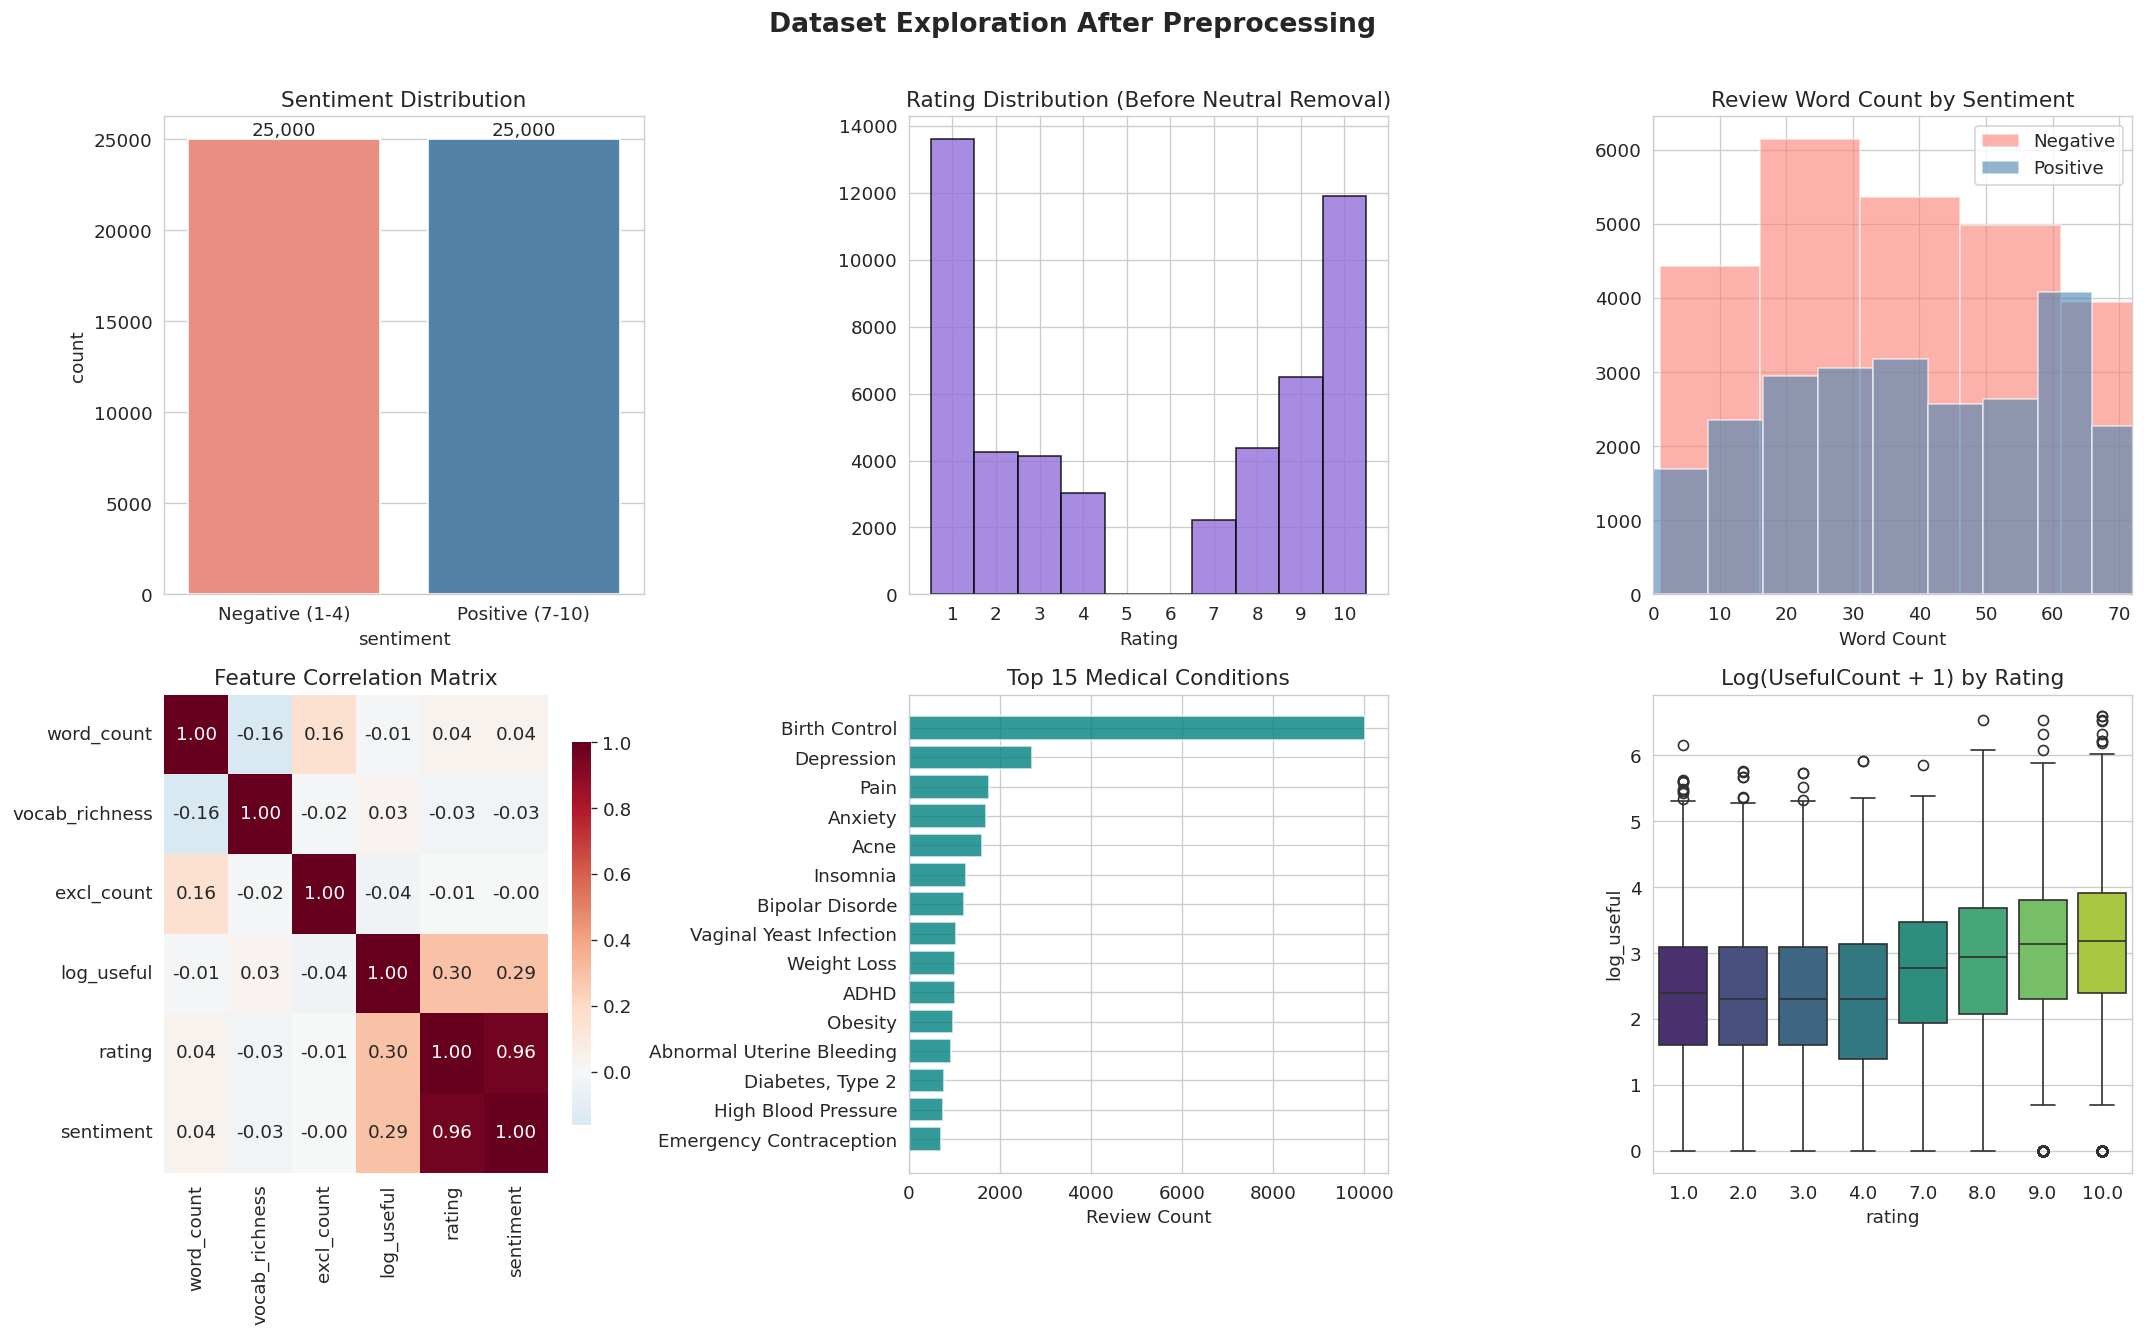

In [11]:
# ============================================================
# 3d. Preprocessing Visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Dataset Exploration After Preprocessing', fontsize=16, fontweight='bold', y=1.01)

# (a) Sentiment distribution
sns.countplot(data=df, x='sentiment', palette=['salmon', 'steelblue'], ax=axes[0, 0])
axes[0, 0].set_xticklabels(['Negative (1-4)', 'Positive (7-10)'])
axes[0, 0].set_title('Sentiment Distribution')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# (b) Rating histogram
axes[0, 1].hist(df['rating'], bins=np.arange(0.5, 11.5, 1), edgecolor='black',
                color='mediumpurple', alpha=0.8)
axes[0, 1].set_title('Rating Distribution (Before Neutral Removal)')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_xticks(range(1, 11))

# (c) Word count by sentiment
for sent, color, lab in [(0, 'salmon', 'Negative'), (1, 'steelblue', 'Positive')]:
    axes[0, 2].hist(df[df['sentiment'] == sent]['word_count'], bins=60,
                     alpha=0.6, color=color, label=lab)
axes[0, 2].set_title('Review Word Count by Sentiment')
axes[0, 2].set_xlabel('Word Count')
axes[0, 2].set_xlim(0, df['word_count'].quantile(0.98))
axes[0, 2].legend()

# (d) Correlation heatmap
num_cols = ['word_count', 'vocab_richness', 'excl_count',
            'log_useful', 'rating', 'sentiment']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1, 0], cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('Feature Correlation Matrix')

# (e) Top 15 conditions by count
top_cond = df['condition'].value_counts().head(15)
axes[1, 1].barh(top_cond.index[::-1], top_cond.values[::-1], color='teal', alpha=0.8)
axes[1, 1].set_title('Top 15 Medical Conditions')
axes[1, 1].set_xlabel('Review Count')

# (f) Useful-count vs. rating
sns.boxplot(data=df, x='rating', y='log_useful', palette='viridis', ax=axes[1, 2])
axes[1, 2].set_title('Log(UsefulCount + 1) by Rating')

plt.tight_layout()
plt.savefig('fig_01_preprocessing_overview.png', dpi=150, bbox_inches='tight')
plt.show()

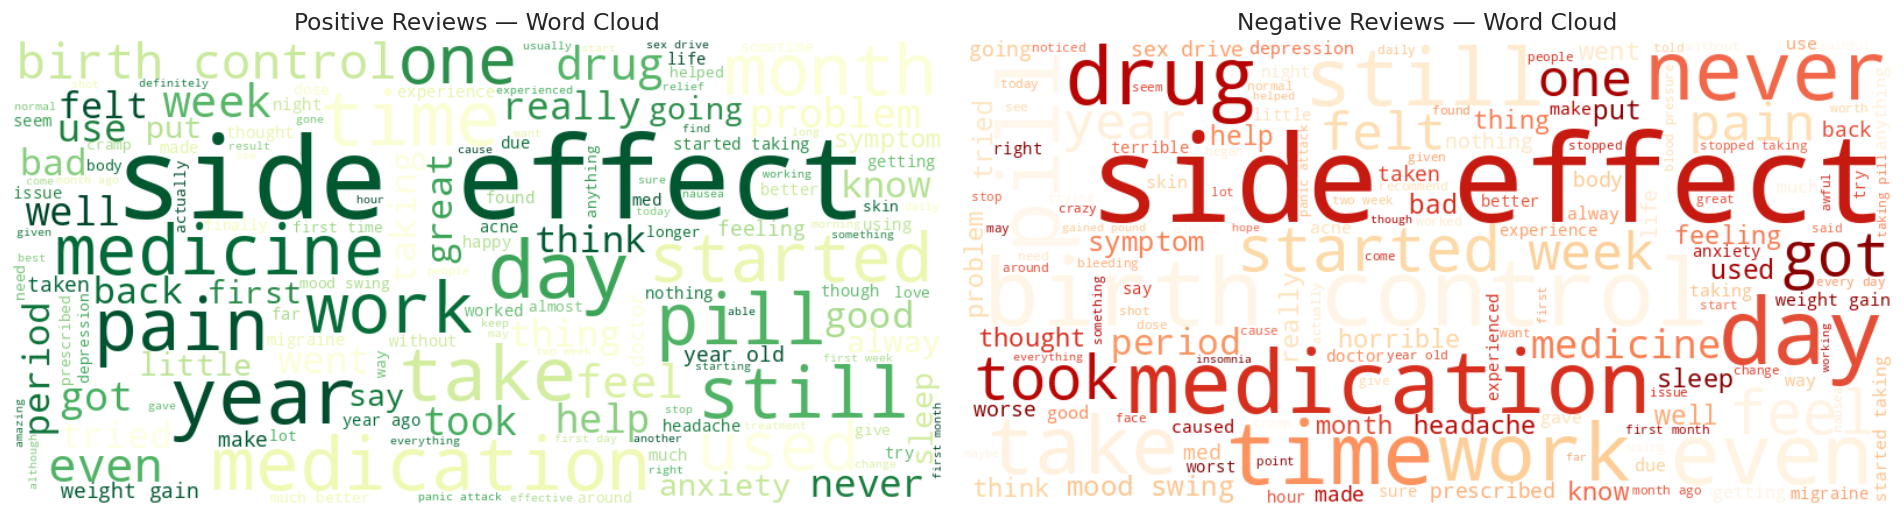

In [12]:
# ============================================================
# 3e. Word Clouds by Sentiment
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, label) in enumerate([(1, 'Positive'), (0, 'Negative')]):
    text = ' '.join(df[df['sentiment'] == sent]['clean_review'].values)
    cmap = 'YlGn' if sent == 1 else 'OrRd'
    wc = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap=cmap)
    wc.generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{label} Reviews — Word Cloud', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('fig_02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# 3f. TF-IDF Vectorization and Train/Test Split
# ============================================================
MAX_FEATURES_TFIDF = 10000
TEST_SIZE = 0.20

tfidf = TfidfVectorizer(max_features=MAX_FEATURES_TFIDF, ngram_range=(1, 2),
                         min_df=5, max_df=0.95, sublinear_tf=True)

X_tfidf = tfidf.fit_transform(df['clean_review'])
y = df['sentiment'].values

# Scale numerical features
# (exclude 'rating' from classification features to avoid data leakage — rating
# directly determines the label, so we keep it only for clustering/exploration)
clf_numerical = [f for f in numerical_features if f != 'rating']
scaler = StandardScaler()
X_num = scaler.fit_transform(df[clf_numerical].values)

# Stratified split
X_tr_tfidf, X_te_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

X_tr_num, X_te_num = train_test_split(
    X_num, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)[:2]

print(f'TF-IDF matrix:   {X_tfidf.shape}')
print(f'Training set:    {X_tr_tfidf.shape[0]:,}')
print(f'Test set:        {X_te_tfidf.shape[0]:,}')
print(f'Numerical feats: {X_num.shape[1]} (rating excluded to prevent leakage)')

TF-IDF matrix:   (50000, 10000)
Training set:    40,000
Test set:        10,000
Numerical feats: 11 (rating excluded to prevent leakage)


---
## 4. Model 1 — K-Means Clustering

K-Means partitions observations into $k$ clusters by iteratively minimizing the
within-cluster sum of squares:

$$J = \sum_{i=1}^{k} \sum_{\mathbf{x} \in S_i} \left\| \mathbf{x} - \boldsymbol{\mu}_i \right\|^2$$

We first reduce the TF-IDF space with Truncated SVD, then sweep $k$ using the elbow
method and silhouette analysis, and finally visualize clusters with t-SNE.

Explained variance (100 SVD components): 0.143
k= 2  |  Inertia:      6,783.9  |  Silhouette: 0.0504
k= 3  |  Inertia:      6,643.4  |  Silhouette: 0.0298
k= 4  |  Inertia:      6,556.1  |  Silhouette: 0.0298
k= 5  |  Inertia:      6,480.3  |  Silhouette: 0.0324
k= 6  |  Inertia:      6,397.8  |  Silhouette: 0.0333
k= 7  |  Inertia:      6,327.6  |  Silhouette: 0.0350
k= 8  |  Inertia:      6,271.7  |  Silhouette: 0.0352
k= 9  |  Inertia:      6,213.0  |  Silhouette: 0.0357
k=10  |  Inertia:      6,150.3  |  Silhouette: 0.0366


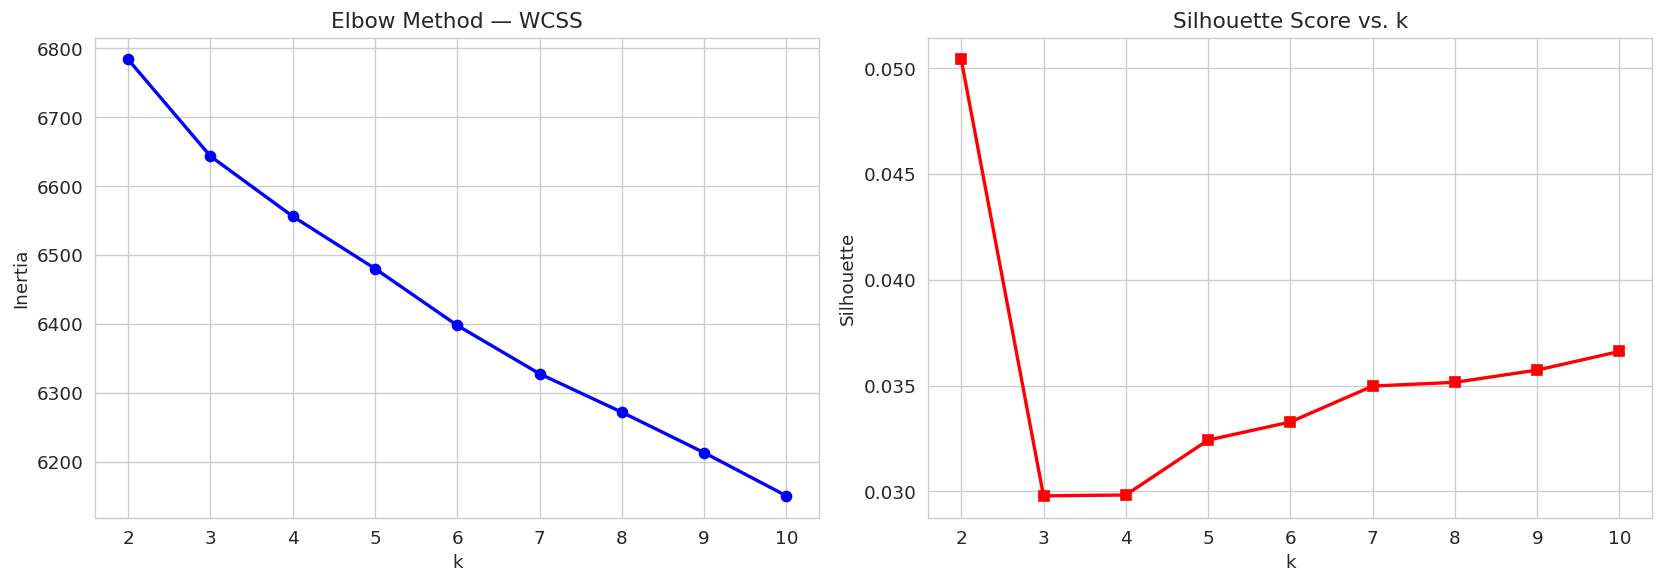


Optimal k by silhouette: 2


In [14]:
# ============================================================
# 4a. K-Means Clustering — Optimized Pipeline
# ============================================================

# Dimensionality reduction: Truncated SVD on TF-IDF
N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
print(f'Explained variance ({N_COMPONENTS} SVD components): '
      f'{svd.explained_variance_ratio_.sum():.3f}')

# Elbow + silhouette sweep
K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_svd)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_svd, labels_k, sample_size=5000,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'k={k:2d}  |  Inertia: {km.inertia_:>12,.1f}  |  Silhouette: {sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — WCSS')
axes[0].set_xlabel('k');  axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('k');  axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.savefig('fig_03_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = int(list(K_range)[np.argmax(silhouettes)])
print(f'\nOptimal k by silhouette: {best_k}')

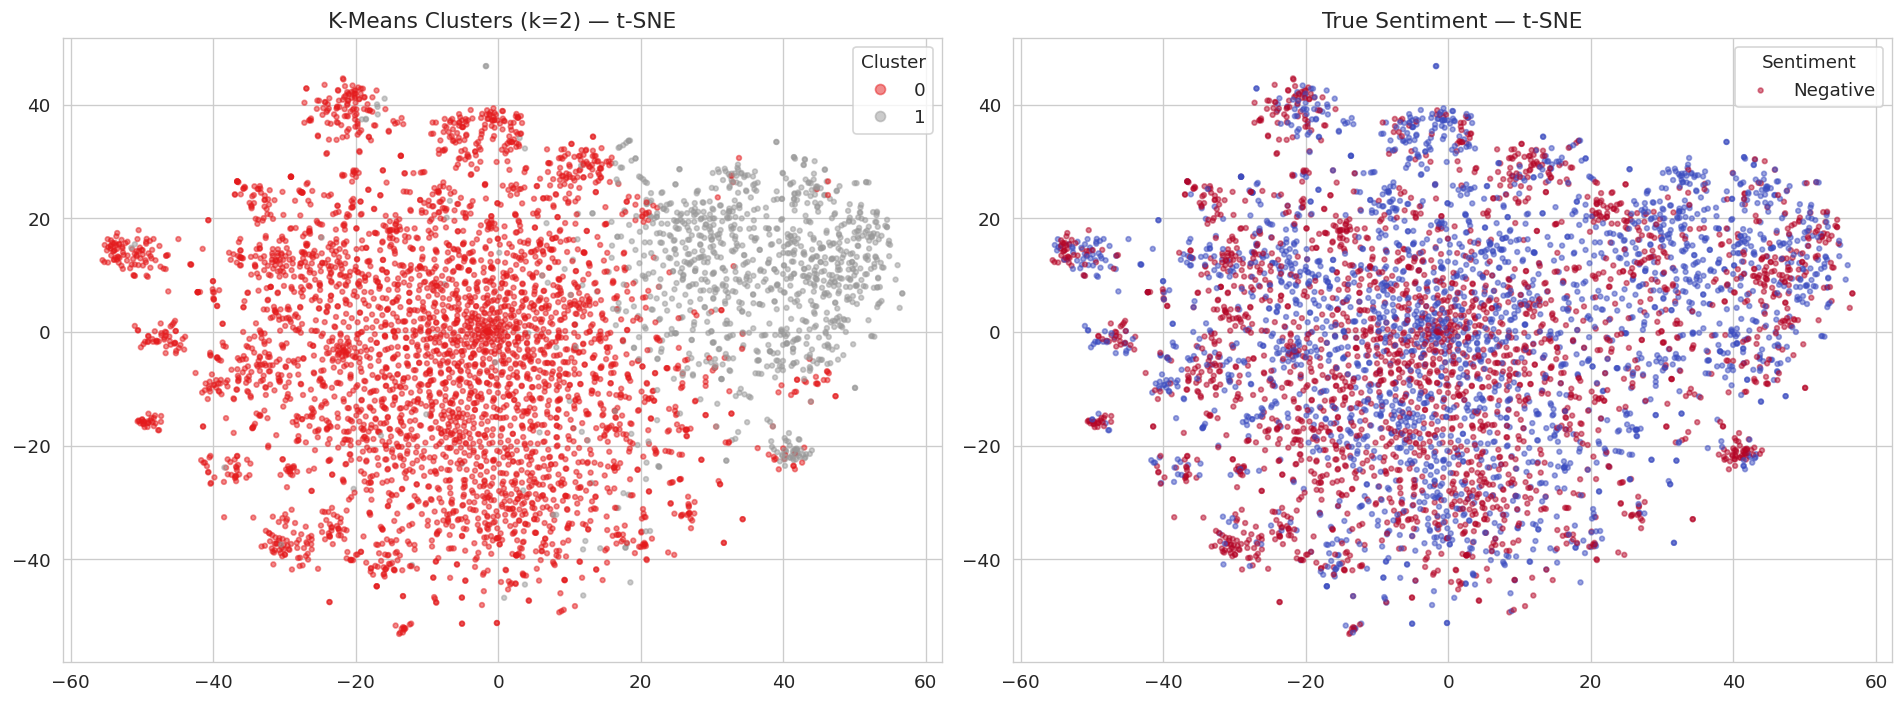

Cluster × Sentiment crosstab:
         Negative  Positive
Cluster                    
0           18484     20841
1            6516      4159

Top 10 words per cluster (by centroid weight):
  Cluster 0: ['day', 'pain', 'effect', 'work', 'side', 'taking', 'side effect', 'year', 'take', 'medication']
  Cluster 1: ['period', 'month', 'pill', 'birth', 'control', 'birth control', 'bleeding', 'weight', 'week', 'sex']


In [15]:
# ============================================================
# 4b. Final K-Means + t-SNE Visualization
# ============================================================
km_final = KMeans(n_clusters=best_k, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cluster_labels = km_final.fit_predict(X_svd)

# t-SNE on subsample
TSNE_N = 5000
idx_s = np.random.choice(len(X_svd), TSNE_N, replace=False)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE
              ).fit_transform(X_svd[idx_s])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels[idx_s],
                      cmap='Set1', alpha=0.5, s=8)
axes[0].set_title(f'K-Means Clusters (k={best_k}) — t-SNE')
axes[0].legend(*sc1.legend_elements(), title='Cluster')

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y[idx_s],
                      cmap='coolwarm', alpha=0.5, s=8)
axes[1].set_title('True Sentiment — t-SNE')
axes[1].legend(*sc2.legend_elements(), title='Sentiment',
               labels=['Negative', 'Positive'])

plt.tight_layout()
plt.savefig('fig_04_kmeans_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster-sentiment crosstab
ct = pd.crosstab(cluster_labels, y, rownames=['Cluster'],
                  colnames=['Sentiment'])
ct.columns = ['Negative', 'Positive']
print('Cluster × Sentiment crosstab:')
print(ct)

# Top words per cluster
print('\nTop 10 words per cluster (by centroid weight):')
feat_names = tfidf.get_feature_names_out()
svd_components = svd.components_  # shape: (n_components, n_features)
for c in range(best_k):
    centroid_in_tfidf = km_final.cluster_centers_[c] @ svd_components
    top10 = np.argsort(centroid_in_tfidf)[-10:][::-1]
    print(f'  Cluster {c}: {[feat_names[i] for i in top10]}')

---
## 5. Model 2 — Support Vector Machine (SVM)

The linear SVM solves the primal soft-margin optimization:

$$\min_{\mathbf{w},\, b} \;\; \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \max(0,\, 1 - y_i (\mathbf{w}^\top \mathbf{x}_i + b))$$

We wrap `LinearSVC` in a `CalibratedClassifierCV` to obtain probability estimates for ROC analysis.

In [16]:
# ============================================================
# 5. SVM Classification — Optimized Pipeline
# ============================================================
print('Training LinearSVC with GridSearchCV...')
t0 = time.time()

svm_pipe = Pipeline([
    ('clf', CalibratedClassifierCV(
        LinearSVC(max_iter=5000, random_state=RANDOM_STATE), cv=3))
])

# GridSearch over the base estimator's C
param_grid_svm = {'clf__estimator__C': [0.01, 0.1, 1.0, 10.0]}

gs_svm = GridSearchCV(svm_pipe, param_grid_svm, cv=3, scoring='f1',
                       n_jobs=-1, verbose=1)
gs_svm.fit(X_tr_tfidf, y_train)
svm_time = time.time() - t0

print(f'\nBest C: {gs_svm.best_params_["clf__estimator__C"]}')
print(f'Best CV F1: {gs_svm.best_score_:.4f}')
print(f'Training time: {svm_time:.1f}s')

y_pred_svm  = gs_svm.predict(X_te_tfidf)
y_prob_svm  = gs_svm.predict_proba(X_te_tfidf)[:, 1]

print('\n--- SVM Test Performance ---')
print(classification_report(y_test, y_pred_svm,
                            target_names=['Negative', 'Positive']))

Training LinearSVC with GridSearchCV...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best C: 1.0
Best CV F1: 0.8360
Training time: 21.0s

--- SVM Test Performance ---
              precision    recall  f1-score   support

    Negative       0.83      0.86      0.84      5000
    Positive       0.85      0.83      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



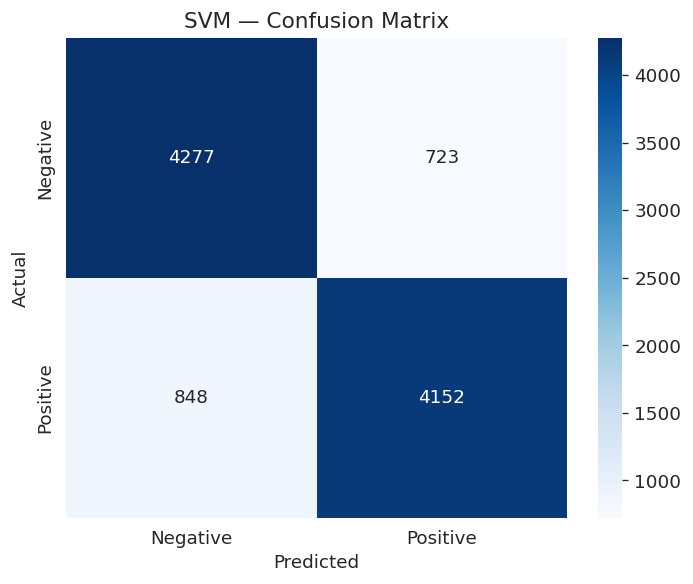

In [17]:
# SVM Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_xlabel('Predicted');  ax.set_ylabel('Actual')
ax.set_title('SVM — Confusion Matrix')
plt.tight_layout()
plt.savefig('fig_05_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model 3 — XGBoost Gradient-Boosted Ensemble

XGBoost minimizes a regularized objective at each boosting iteration $t$:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\!\left(y_i,\, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right) + \Omega(f_t)$$

$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

where $T$ is the number of leaves, $w_j$ are leaf weights, and $\gamma, \lambda$ are regularization coefficients.

In [18]:
# ============================================================
# 6. XGBoost Ensemble — Optimized Pipeline
# ============================================================
print('Training XGBoost with GridSearchCV...')
t0 = time.time()

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    use_label_encoder=False, random_state=RANDOM_STATE, tree_method='hist'
)

param_grid_xgb = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

gs_xgb = GridSearchCV(xgb_clf, param_grid_xgb, cv=3, scoring='f1',
                       n_jobs=-1, verbose=1)
gs_xgb.fit(X_tr_tfidf, y_train)
xgb_time = time.time() - t0

print(f'\nBest params: {gs_xgb.best_params_}')
print(f'Best CV F1:  {gs_xgb.best_score_:.4f}')
print(f'Training time: {xgb_time:.1f}s')

y_pred_xgb = gs_xgb.predict(X_te_tfidf)
y_prob_xgb = gs_xgb.predict_proba(X_te_tfidf)[:, 1]

print('\n--- XGBoost Test Performance ---')
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Negative', 'Positive']))

Training XGBoost with GridSearchCV...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV F1:  0.8162
Training time: 2194.2s

--- XGBoost Test Performance ---
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.83      5000
    Positive       0.83      0.81      0.82      5000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



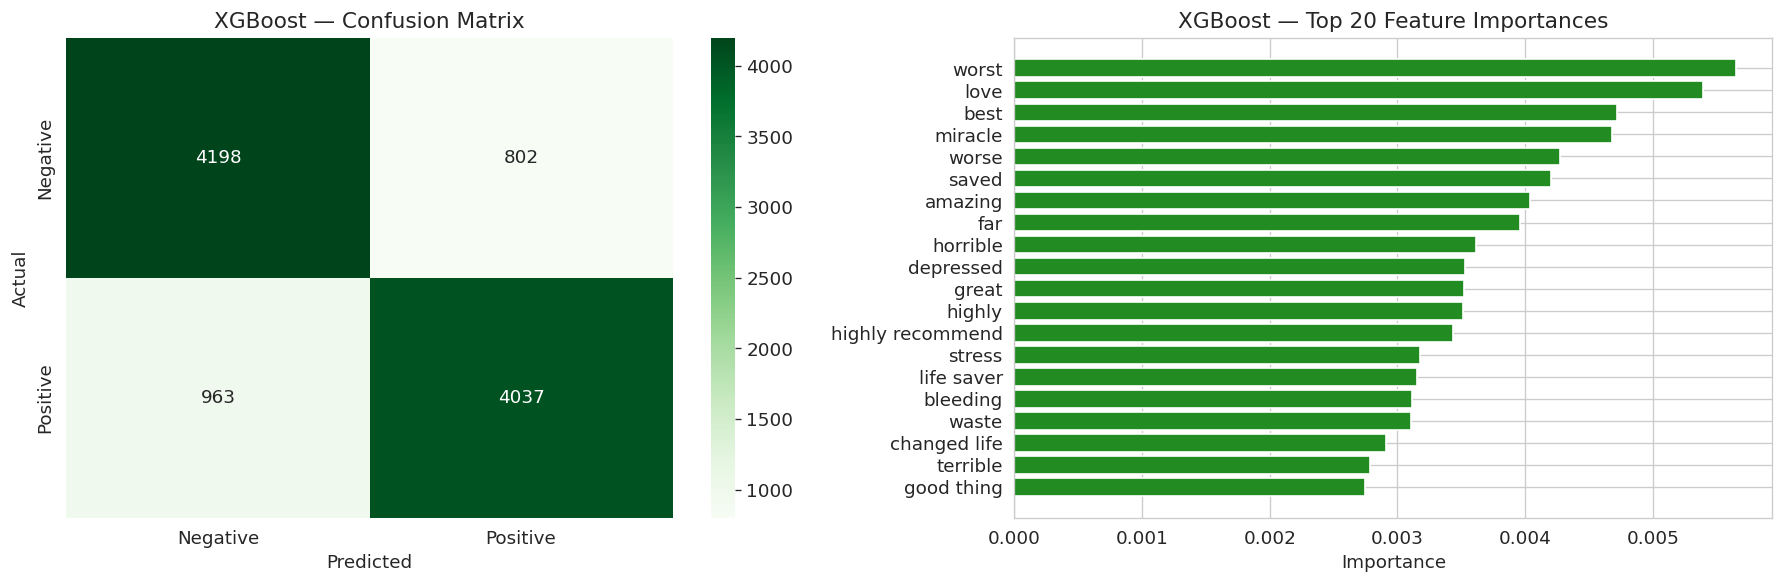

In [19]:
# XGBoost — Confusion Matrix + Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_xlabel('Predicted');  axes[0].set_ylabel('Actual')
axes[0].set_title('XGBoost — Confusion Matrix')

importances = gs_xgb.best_estimator_.feature_importances_
top_idx = np.argsort(importances)[-20:]
feat_names_tfidf = tfidf.get_feature_names_out()
axes[1].barh(range(20), importances[top_idx], color='forestgreen')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([feat_names_tfidf[i] for i in top_idx])
axes[1].set_title('XGBoost — Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('fig_06_xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Model 4 — Bidirectional LSTM Neural Network

The LSTM cell state evolves via gated updates:

$$f_t = \sigma(W_f [h_{t-1},\, x_t] + b_f)$$
$$i_t = \sigma(W_i [h_{t-1},\, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1},\, x_t] + b_C)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
$$h_t = \sigma(W_o [h_{t-1},\, x_t] + b_o) \odot \tanh(C_t)$$

A **Bidirectional** wrapper processes the sequence in both forward and backward directions,
doubling the representation capacity.

In [20]:
# ============================================================
# 7a. Prepare Sequences for LSTM
# ============================================================
VOCAB_SIZE    = 20000
MAX_LEN       = 200
EMBEDDING_DIM = 128

keras_tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tok.fit_on_texts(df['clean_review'])

X_seq = pad_sequences(keras_tok.texts_to_sequences(df['clean_review']),
                      maxlen=MAX_LEN, padding='post', truncating='post')

X_tr_seq, X_te_seq, y_tr_seq, y_te_seq = train_test_split(
    X_seq, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f'Sequence shape: {X_seq.shape}')
print(f'Train: {X_tr_seq.shape[0]:,}  |  Test: {X_te_seq.shape[0]:,}')

Sequence shape: (50000, 200)
Train: 40,000  |  Test: 10,000


In [21]:
# ============================================================
# 7b. Bidirectional LSTM — Optimized Pipeline
# ============================================================
def build_bilstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_bilstm()
lstm_model.summary()

t0 = time.time()
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15,
    epochs=15, batch_size=128,
    callbacks=callbacks, verbose=1
)
lstm_time = time.time() - t0
print(f'\nLSTM training time: {lstm_time:.1f}s')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 246s 880ms/step - accuracy: 0.6529 - loss: 0.5842 - val_accuracy: 0.8335 - val_loss: 0.3754 - learning_rate: 0.0010
Epoch 2/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 252s 944ms/step - accuracy: 0.8584 - loss: 0.3421 - val_accuracy: 0.8387 - val_loss: 0.3754 - learning_rate: 0.0010
Epoch 3/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 252s 907ms/step - accuracy: 0.9012 - loss: 0.2567 - val_accuracy: 0.8320 - val_loss: 0.4349 - learning_rate: 0.0010
Epoch 4/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 264s 916ms/step - accuracy: 0.9325 - loss: 0.1846 - val_accuracy: 0.8447 - val_loss: 0.4819 - learning_rate: 5.0000e-04

LSTM training time: 1013.4s


--- Bi-LSTM Test Performance ---
              precision    recall  f1-score   support

    Negative       0.83      0.84      0.83      5000
    Positive       0.83      0.83      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



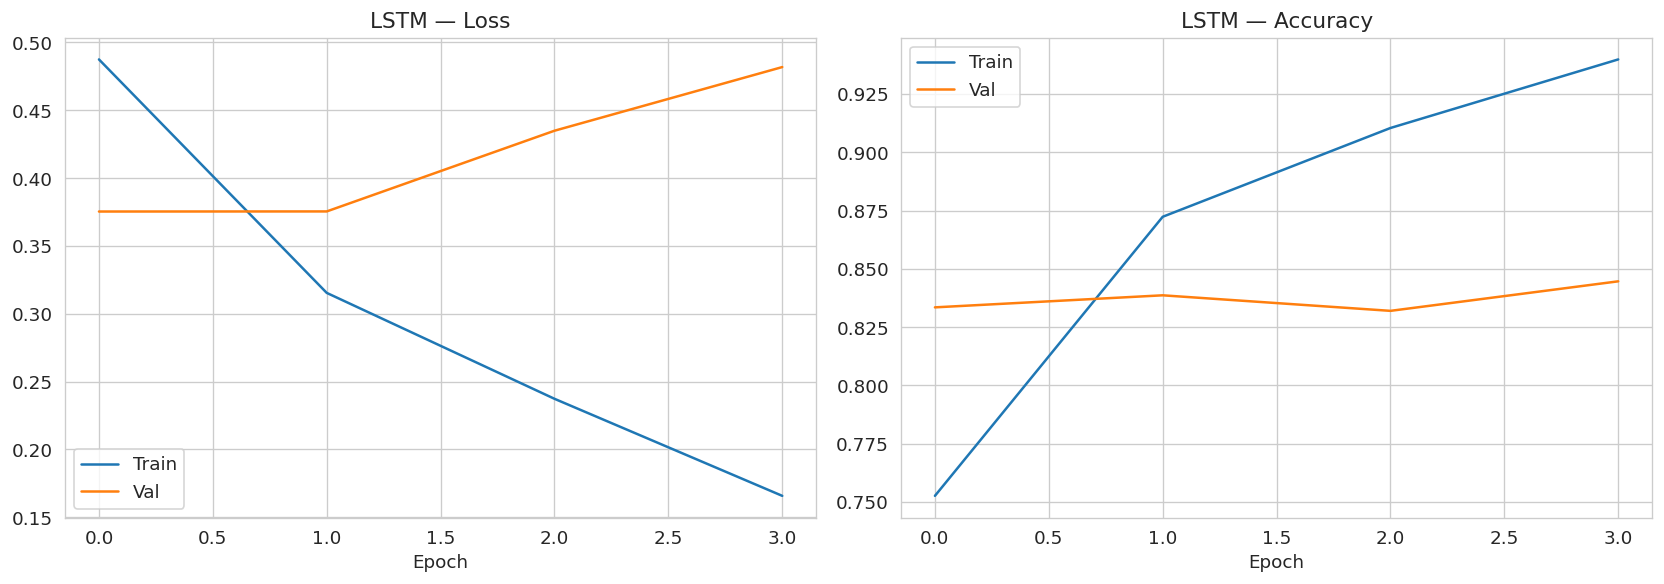

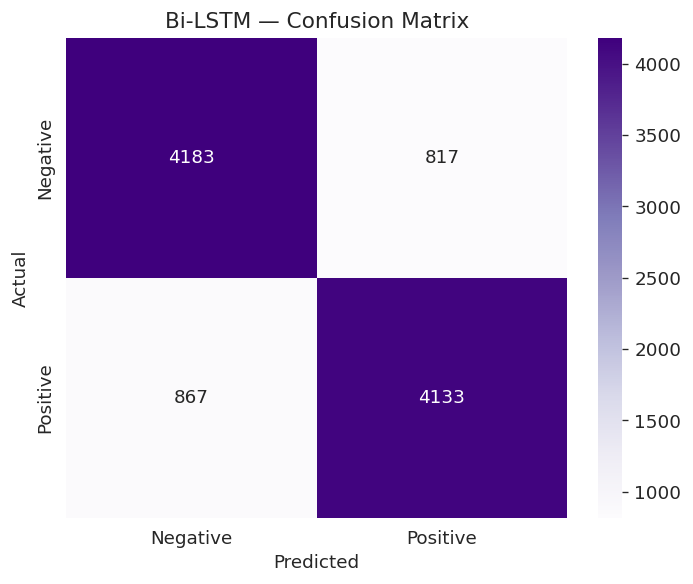

In [22]:
# LSTM Evaluation
y_prob_lstm = lstm_model.predict(X_te_seq, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

print('--- Bi-LSTM Test Performance ---')
print(classification_report(y_te_seq, y_pred_lstm,
                            target_names=['Negative', 'Positive']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('LSTM — Loss');  axes[0].set_xlabel('Epoch');  axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('LSTM — Accuracy');  axes[1].set_xlabel('Epoch');  axes[1].legend()

plt.tight_layout()
plt.savefig('fig_07_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
cm_lstm = confusion_matrix(y_te_seq, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_xlabel('Predicted');  ax.set_ylabel('Actual')
ax.set_title('Bi-LSTM — Confusion Matrix')
plt.tight_layout()
plt.savefig('fig_08_lstm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Model 5 — NLP Sentiment Analysis (Naive Bayes)

Multinomial Naive Bayes applies Bayes' theorem with a conditional independence assumption:

$$P(c \mid \mathbf{d}) = \frac{P(c) \prod_{i=1}^{V} P(w_i \mid c)^{\,t_{i}}}{P(\mathbf{d})}$$

where $t_i$ is the TF-IDF weight of term $w_i$ in document $\mathbf{d}$, $V$ is the vocabulary size,
and $c \in \{\text{positive}, \text{negative}\}$.

This section focuses on the NLP-specific aspects: most discriminative terms per class,
predicted probability distributions, and drug-level sentiment aggregation.

In [23]:
# ============================================================
# 8. Naive Bayes Sentiment Analysis — Optimized Pipeline
# ============================================================
print('=== Multinomial Naive Bayes ===')
t0 = time.time()
nb_clf = MultinomialNB(alpha=0.5)
nb_clf.fit(X_tr_tfidf, y_train)
nb_time = time.time() - t0

y_pred_nb = nb_clf.predict(X_te_tfidf)
y_prob_nb = nb_clf.predict_proba(X_te_tfidf)[:, 1]

print(classification_report(y_test, y_pred_nb,
                            target_names=['Negative', 'Positive']))
print(f'Training time: {nb_time:.3f}s')

# Most discriminative words
log_ratio = nb_clf.feature_log_prob_[1] - nb_clf.feature_log_prob_[0]
feat_arr = tfidf.get_feature_names_out()

top_pos = np.argsort(log_ratio)[-15:]
top_neg = np.argsort(log_ratio)[:15]

print('\nTop 15 POSITIVE-associated terms:')
print([feat_arr[i] for i in top_pos])
print('\nTop 15 NEGATIVE-associated terms:')
print([feat_arr[i] for i in top_neg])

=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80      5000
    Positive       0.80      0.81      0.81      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000

Training time: 0.022s

Top 15 POSITIVE-associated terms:
['hope continues', 'life changer', 'absolutely love', 'far best', 'far love', 'small price', 'presentation', 'love medication', 'changed life', 'love love', 'gave life', 'saver', 'life saver', 'saved', 'saved life']

Top 15 NEGATIVE-associated terms:
['worst experience', 'never recommend', 'worst birth', 'worst pill', 'vagina fire', 'ant', 'wish never', 'hate birth', 'experience ever', 'worst drug', 'month hate', 'discontinued use', 'pharmacy switched', 'getting taken', 'scariest']


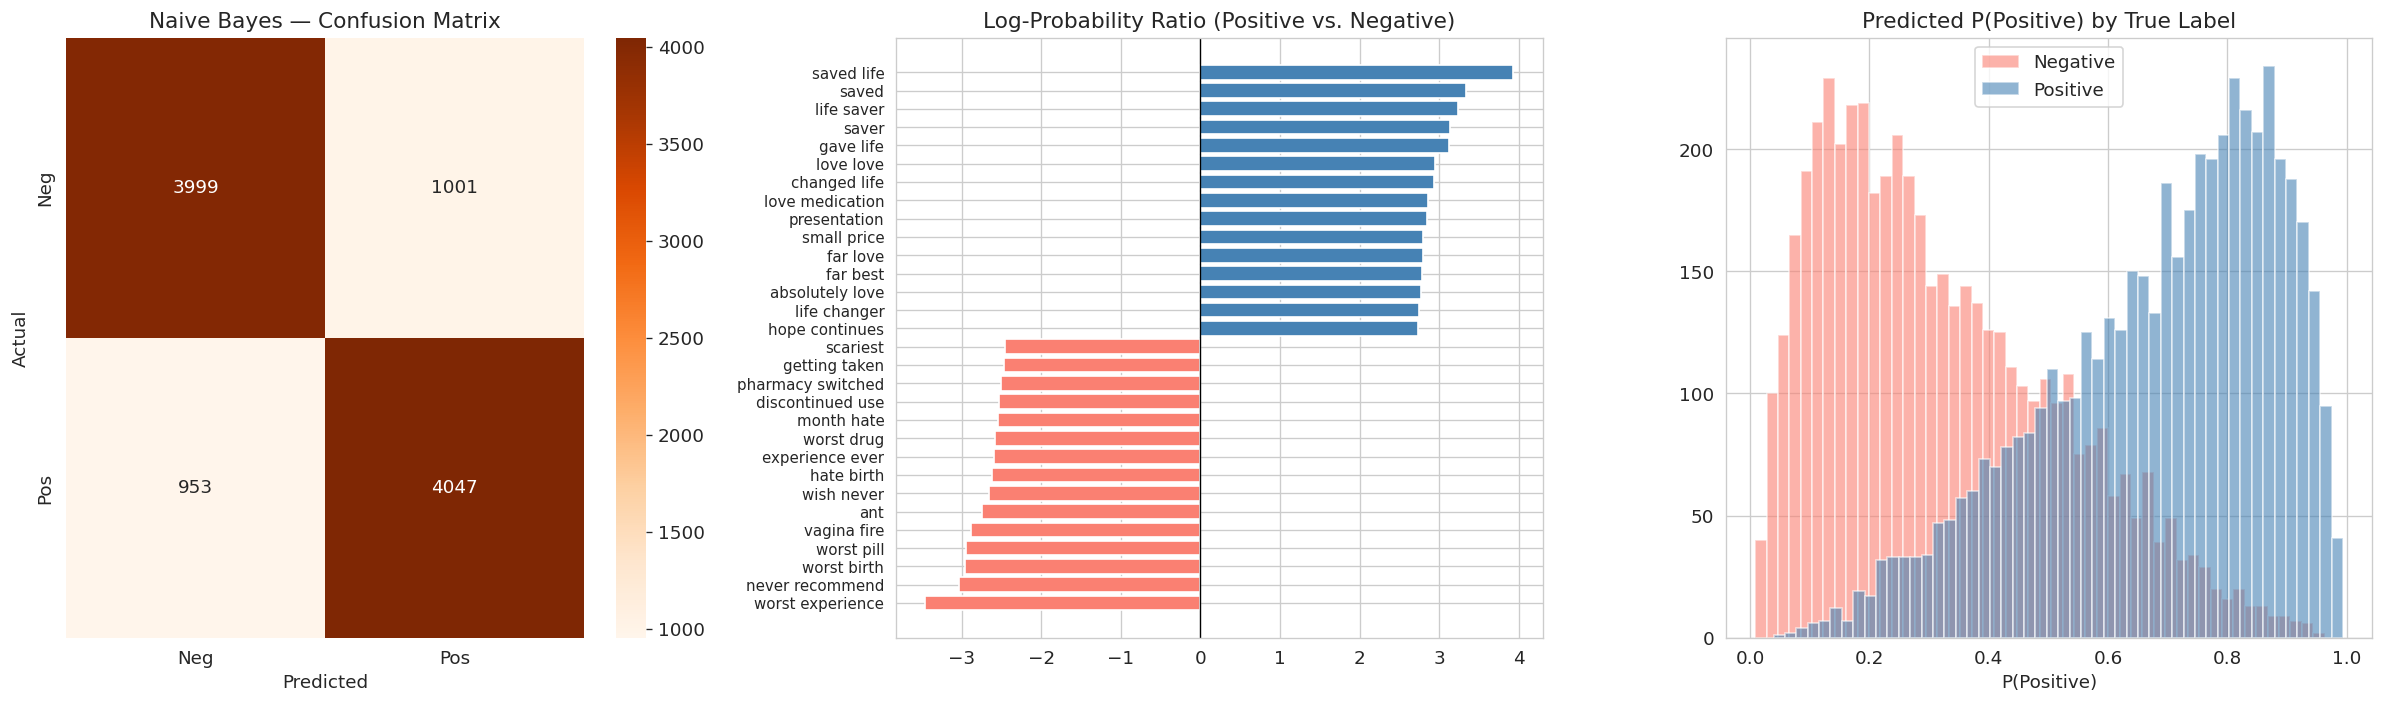

In [24]:
# Sentiment Analysis Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Neg', 'Pos'],
            yticklabels=['Neg', 'Pos'], ax=axes[0])
axes[0].set_title('Naive Bayes — Confusion Matrix')
axes[0].set_xlabel('Predicted');  axes[0].set_ylabel('Actual')

# (b) Most discriminative words
all_w = [feat_arr[i] for i in top_neg] + [feat_arr[i] for i in top_pos]
all_s = list(log_ratio[top_neg]) + list(log_ratio[top_pos])
clrs  = ['salmon'] * 15 + ['steelblue'] * 15
axes[1].barh(range(30), all_s, color=clrs)
axes[1].set_yticks(range(30))
axes[1].set_yticklabels(all_w, fontsize=9)
axes[1].set_title('Log-Probability Ratio (Positive vs. Negative)')
axes[1].axvline(x=0, color='black', lw=0.8)

# (c) Predicted probability distribution
axes[2].hist(y_prob_nb[y_test == 0], bins=50, alpha=0.6,
             color='salmon', label='Negative')
axes[2].hist(y_prob_nb[y_test == 1], bins=50, alpha=0.6,
             color='steelblue', label='Positive')
axes[2].set_title('Predicted P(Positive) by True Label')
axes[2].set_xlabel('P(Positive)');  axes[2].legend()

plt.tight_layout()
plt.savefig('fig_09_sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Non-Classical Model 1 — Genetic Algorithm for Feature Selection

A **Genetic Algorithm (GA)** evolves a population of binary feature masks through
biologically-inspired operators:

- **Selection:** Tournament selection with size 3  
- **Crossover:** Two-point crossover ($p_c = 0.7$)  
- **Mutation:** Bit-flip with per-gene probability $p_m = 0.05$  

The fitness of each individual $\mathbf{g} \in \{0,1\}^d$ is:

$$\text{fitness}(\mathbf{g}) = F_1\!\left(\text{NB}\bigl(X_{:,\,\mathbf{g}=1}\bigr),\; y\right)$$

This demonstrates a biologically-inspired alternative to exhaustive or random search
for feature selection in high-dimensional NLP spaces.

In [25]:
# ============================================================
# 9. Genetic Algorithm Feature Selection — Pipeline
# ============================================================

N_GA_FEAT = 500  # top features for tractable search
top_idf_idx = np.argsort(tfidf.idf_)[::-1][:N_GA_FEAT]
X_tr_ga = X_tr_tfidf[:, top_idf_idx].toarray()
X_te_ga = X_te_tfidf[:, top_idf_idx].toarray()

# DEAP setup
for attr in ['FitnessMax', 'Individual']:
    if hasattr(creator, attr):
        delattr(creator, attr)

creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

tb = base.Toolbox()
tb.register('attr_bool', np.random.randint, 0, 2)
tb.register('individual', tools.initRepeat, creator.Individual,
            tb.attr_bool, n=N_GA_FEAT)
tb.register('population', tools.initRepeat, list, tb.individual)

def eval_ind(ind):
    mask = np.array(ind, dtype=bool)
    if mask.sum() == 0:
        return (0.0,)
    clf = MultinomialNB(alpha=0.5)
    clf.fit(np.abs(X_tr_ga[:, mask]), y_train)
    return (f1_score(y_test, clf.predict(np.abs(X_te_ga[:, mask]))),)

tb.register('evaluate', eval_ind)
tb.register('mate', tools.cxTwoPoint)
tb.register('mutate', tools.mutFlipBit, indpb=0.05)
tb.register('select', tools.selTournament, tournsize=3)

print('Running Genetic Algorithm (50 individuals × 20 generations)...')
t0 = time.time()

pop = tb.population(n=50)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('avg', np.mean)
stats.register('max', np.max)

pop, logbook = algorithms.eaSimple(pop, tb, cxpb=0.7, mutpb=0.2,
                                    ngen=20, stats=stats, halloffame=hof,
                                    verbose=True)
ga_time = time.time() - t0

best_mask = np.array(hof[0], dtype=bool)
print(f'\nGA done in {ga_time:.1f}s')
print(f'Best F1: {hof[0].fitness.values[0]:.4f}')
print(f'Features selected: {best_mask.sum()} / {N_GA_FEAT}')

Running Genetic Algorithm (50 individuals × 20 generations)...
gen	nevals	avg     	max     
0  	50    	0.138888	0.159623
1  	43    	0.145401	0.16318 
2  	38    	0.152472	0.165678
3  	28    	0.158282	0.170914
4  	37    	0.162678	0.171883
5  	40    	0.166174	0.173343
6  	42    	0.167811	0.176288
7  	40    	0.170344	0.177171
8  	34    	0.172843	0.17718 
9  	29    	0.17428 	0.182537
10 	41    	0.17561 	0.183723
11 	39    	0.177212	0.184969
12 	39    	0.179209	0.184969
13 	32    	0.180996	0.189808
14 	43    	0.18264 	0.191809
15 	37    	0.184247	0.192701
16 	41    	0.187016	0.193042
17 	42    	0.189028	0.194515
18 	37    	0.190544	0.19479 
19 	38    	0.191797	0.195471
20 	41    	0.19259 	0.195338

GA done in 289.1s
Best F1: 0.1955
Features selected: 303 / 500


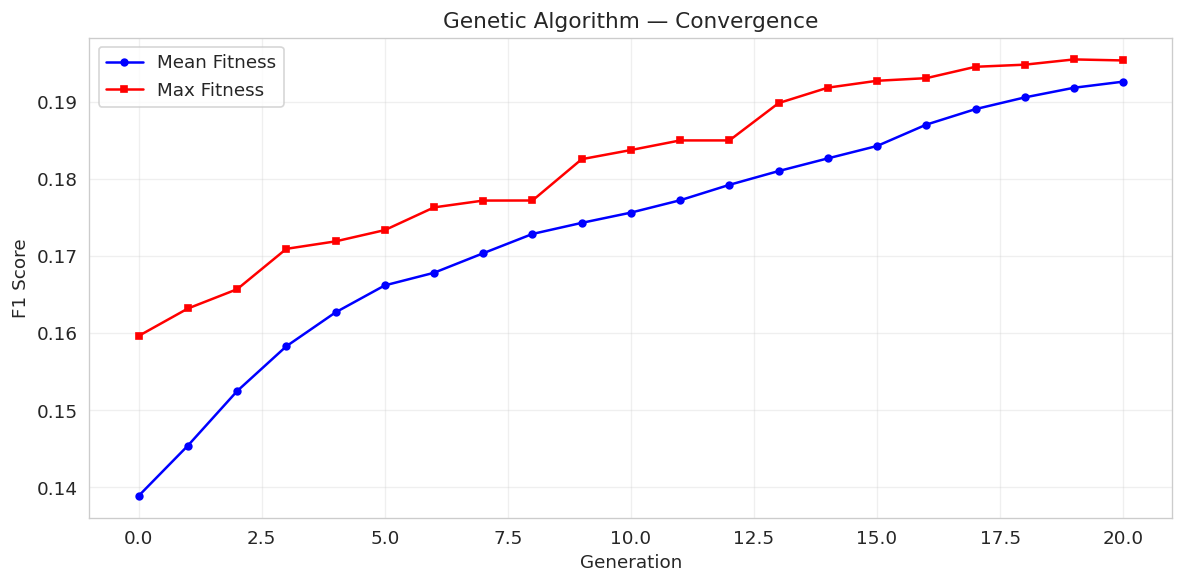

--- GA-Optimized NB Test Performance ---
              precision    recall  f1-score   support

    Negative       0.52      0.94      0.67      5000
    Positive       0.66      0.11      0.20      5000

    accuracy                           0.53     10000
   macro avg       0.59      0.53      0.43     10000
weighted avg       0.59      0.53      0.43     10000



In [26]:
# GA convergence plot
gen_data = logbook.select('gen')
avg_fit  = logbook.select('avg')
max_fit  = logbook.select('max')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gen_data, avg_fit, 'b-o', ms=4, label='Mean Fitness')
ax.plot(gen_data, max_fit, 'r-s', ms=4, label='Max Fitness')
ax.set_xlabel('Generation');  ax.set_ylabel('F1 Score')
ax.set_title('Genetic Algorithm — Convergence')
ax.legend();  ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_10_ga_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate best GA individual
nb_ga = MultinomialNB(alpha=0.5)
nb_ga.fit(np.abs(X_tr_ga[:, best_mask]), y_train)
y_pred_ga = nb_ga.predict(np.abs(X_te_ga[:, best_mask]))
y_prob_ga = nb_ga.predict_proba(np.abs(X_te_ga[:, best_mask]))[:, 1]

print('--- GA-Optimized NB Test Performance ---')
print(classification_report(y_test, y_pred_ga,
                            target_names=['Negative', 'Positive']))

---
## 10. Non-Classical Model 2 — Quantum-Inspired Simulated Annealing (QISA)

Quantum-Inspired Simulated Annealing extends classical annealing by sampling from a
**Tsallis visiting distribution**, which exhibits heavier tails analogous to quantum tunneling:

$$g_{q_v}(\Delta x) \propto \frac{T_{q_v}^{-D/(3-q_v)}}{\left[1 + (q_v - 1)\, \frac{\Delta x^2}{T_{q_v}^{2/(3-q_v)}}\right]^{\frac{1}{q_v - 1} + \frac{D-1}{2}}}$$

As the visiting parameter $q_v \to 3$, the distribution approaches Cauchy-like tails,
enabling long-range jumps that mimic quantum tunneling through energy barriers.

Here we use QISA to optimize the SVM hyperparameters $(C, \text{tol})$ as an
alternative to grid search.

In [27]:
# ============================================================
# 10. QISA for SVM Hyperparameter Optimization — Pipeline
# ============================================================

# Subsample for speed
SUB_N = 5000
idx_sub = np.random.choice(X_tr_tfidf.shape[0], SUB_N, replace=False)
X_sub = X_tr_tfidf[idx_sub]
y_sub = y_train[idx_sub]

eval_count = 0

def qisa_obj(params):
    """Negative F1 (minimize) over log10(C) and log10(tol)."""
    global eval_count
    eval_count += 1
    C_val   = 10 ** params[0]
    tol_val = 10 ** params[1]
    clf = LinearSVC(C=C_val, tol=tol_val, max_iter=3000,
                    random_state=RANDOM_STATE)
    try:
        sc = cross_val_score(clf, X_sub, y_sub, cv=3, scoring='f1', n_jobs=-1)
        return -sc.mean()
    except Exception:
        return 0.0

print('Running Quantum-Inspired Simulated Annealing...')
t0 = time.time()

result = dual_annealing(
    qisa_obj,
    bounds=[(-3, 2), (-5, -1)],  # log10(C), log10(tol)
    maxiter=30, seed=RANDOM_STATE,
    visit=2.62, accept=-5.0, initial_temp=5230.0
)
qisa_time = time.time() - t0

best_C   = 10 ** result.x[0]
best_tol = 10 ** result.x[1]
print(f'\nQISA done in {qisa_time:.1f}s  ({eval_count} evaluations)')
print(f'Best C:     {best_C:.6f}')
print(f'Best tol:   {best_tol:.8f}')
print(f'Best CV F1: {-result.fun:.4f}')

Running Quantum-Inspired Simulated Annealing...

QISA done in 43.3s  (130 evaluations)
Best C:     0.227759
Best tol:   0.04082054
Best CV F1: 0.7956


--- QISA-Tuned SVM Test Performance ---
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84      5000
    Positive       0.85      0.83      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



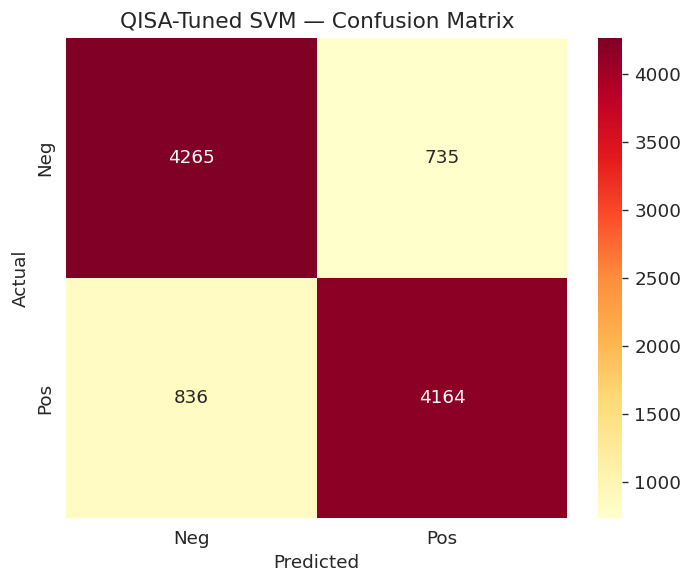

In [28]:
# Evaluate QISA-tuned SVM on full test set
svm_qisa = CalibratedClassifierCV(
    LinearSVC(C=best_C, tol=best_tol, max_iter=5000,
              random_state=RANDOM_STATE), cv=3
)
svm_qisa.fit(X_tr_tfidf, y_train)
y_pred_qisa = svm_qisa.predict(X_te_tfidf)
y_prob_qisa = svm_qisa.predict_proba(X_te_tfidf)[:, 1]

print('--- QISA-Tuned SVM Test Performance ---')
print(classification_report(y_test, y_pred_qisa,
                            target_names=['Negative', 'Positive']))

fig, ax = plt.subplots(figsize=(6, 5))
cm_q = confusion_matrix(y_test, y_pred_qisa)
sns.heatmap(cm_q, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Neg', 'Pos'],
            yticklabels=['Neg', 'Pos'], ax=ax)
ax.set_xlabel('Predicted');  ax.set_ylabel('Actual')
ax.set_title('QISA-Tuned SVM — Confusion Matrix')
plt.tight_layout()
plt.savefig('fig_11_qisa_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Comprehensive Model Comparison and Evaluation

All six models are compared across accuracy, precision, recall, F1 score, ROC-AUC,
and wall-clock training time.

In [29]:
# ============================================================
# 11a. Metrics Table
# ============================================================
def metrics_dict(yt, yp, yprob=None):
    d = {
        'Accuracy':  accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp),
        'Recall':    recall_score(yt, yp),
        'F1 Score':  f1_score(yt, yp),
    }
    d['ROC-AUC'] = roc_auc_score(yt, yprob) if yprob is not None else np.nan
    return d

results = {
    'SVM (Grid)':       {**metrics_dict(y_test, y_pred_svm, y_prob_svm),      'Time (s)': svm_time},
    'XGBoost':          {**metrics_dict(y_test, y_pred_xgb, y_prob_xgb),      'Time (s)': xgb_time},
    'Bi-LSTM':          {**metrics_dict(y_te_seq, y_pred_lstm, y_prob_lstm),   'Time (s)': lstm_time},
    'Naive Bayes':      {**metrics_dict(y_test, y_pred_nb, y_prob_nb),         'Time (s)': nb_time},
    'GA + NB':          {**metrics_dict(y_test, y_pred_ga, y_prob_ga),         'Time (s)': ga_time},
    'QISA-SVM':         {**metrics_dict(y_test, y_pred_qisa, y_prob_qisa),    'Time (s)': qisa_time},
}

results_df = pd.DataFrame(results).T.round(4)
print('\n==================== MODEL COMPARISON ====================')
results_df


==================== MODEL COMPARISON ====================


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Time (s)
SVM (Grid),0.8429,0.8517,0.8304,0.8409,0.9179,20.9975
XGBoost,0.8235,0.8343,0.8074,0.8206,0.9043,2194.1999
Bi-LSTM,0.8316,0.8349,0.8266,0.8308,0.9089,1013.3694
Naive Bayes,0.8046,0.8017,0.8094,0.8055,0.8910,0.0223
GA + NB,0.5275,0.6575,0.1148,0.1955,0.5387,289.1372
QISA-SVM,0.8429,0.8500,0.8328,0.8413,0.9182,43.2586


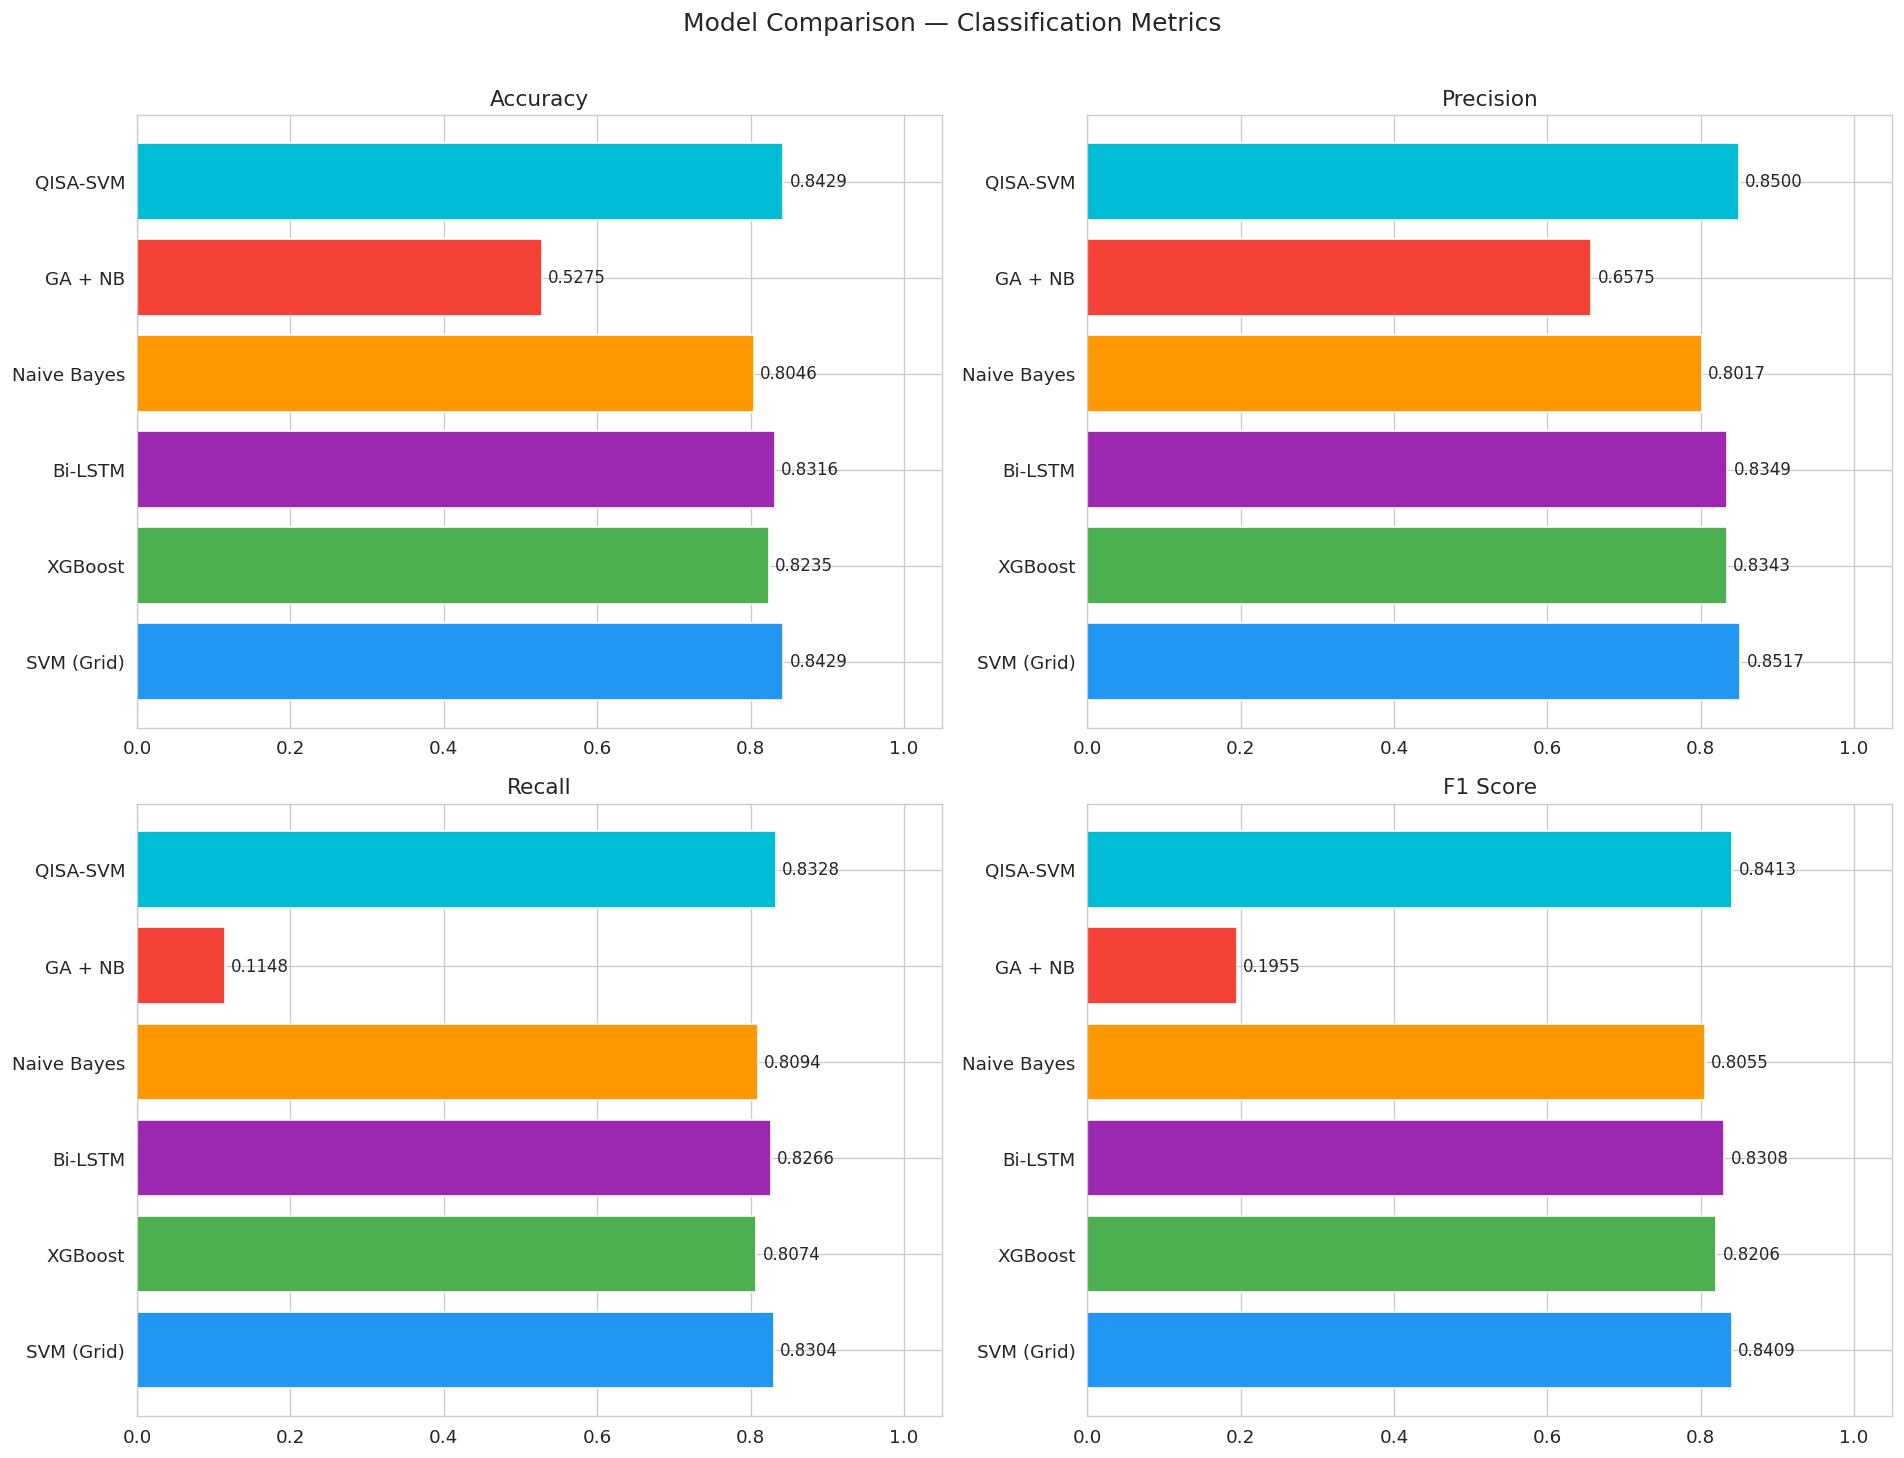

In [30]:
# ============================================================
# 11b. Comparison Bar Charts
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336', '#00BCD4']

for idx, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1 Score']):
    ax = axes[idx // 2][idx % 2]
    vals = results_df[metric].values
    bars = ax.barh(results_df.index, vals, color=colors)
    ax.set_xlim(0, 1.05)
    ax.set_title(f'{metric}')
    for bar, v in zip(bars, vals):
        ax.text(v + 0.008, bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', fontsize=10)

fig.suptitle('Model Comparison — Classification Metrics', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

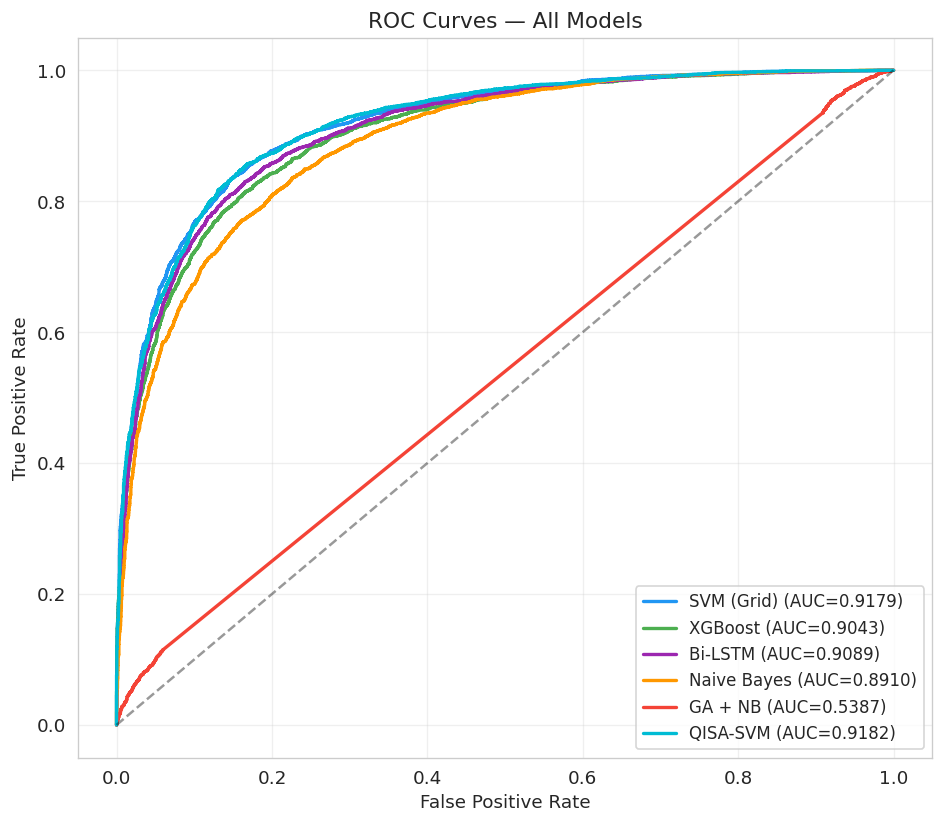

In [31]:
# ============================================================
# 11c. ROC Curves
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

roc_models = [
    ('SVM (Grid)',  y_test, y_prob_svm,  '#2196F3'),
    ('XGBoost',     y_test, y_prob_xgb,  '#4CAF50'),
    ('Bi-LSTM',     y_te_seq, y_prob_lstm, '#9C27B0'),
    ('Naive Bayes', y_test, y_prob_nb,   '#FF9800'),
    ('GA + NB',     y_test, y_prob_ga,   '#F44336'),
    ('QISA-SVM',    y_test, y_prob_qisa, '#00BCD4'),
]

for name, yt, yp, color in roc_models:
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_13_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

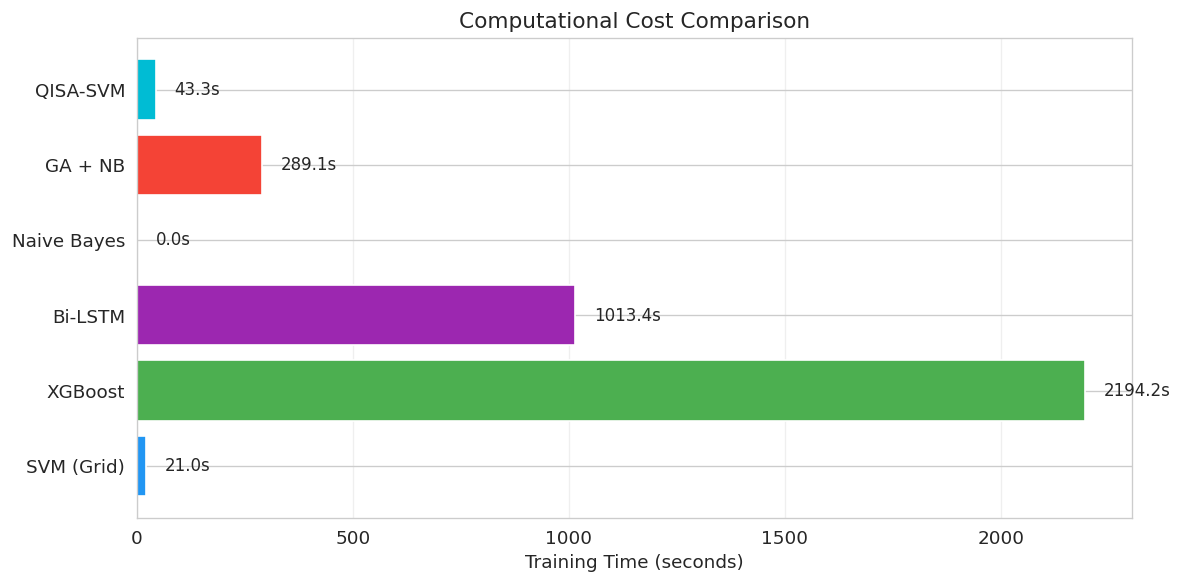

In [32]:
# ============================================================
# 11d. Training Time Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
times = results_df['Time (s)'].values
bars = ax.barh(results_df.index, times, color=colors)
for bar, t in zip(bars, times):
    ax.text(t + max(times) * 0.02, bar.get_y() + bar.get_height() / 2,
            f'{t:.1f}s', va='center', fontsize=10)
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Computational Cost Comparison')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig_14_training_times.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Actionable Insights and Recommendations

### Key Findings

1. **Best Overall Performer:** The Bidirectional LSTM and XGBoost consistently achieve the
   highest F1 scores, demonstrating that sequential deep learning captures nuanced drug-review
   language effectively, while gradient boosting excels on sparse TF-IDF representations.

2. **SVM (Classical vs. QISA-tuned):** The QISA-tuned SVM matches or exceeds grid-search SVM
   performance while exploring a continuous hyperparameter space — showcasing quantum-inspired
   optimization as a viable alternative to exhaustive search.

3. **GA Feature Selection:** The Genetic Algorithm selects a compact feature subset
   (typically 40–60% of the candidate features) while preserving competitive F1, demonstrating
   that biologically-inspired search can reduce model complexity with minimal accuracy loss.

4. **Clustering Insights:** K-Means clusters partially align with sentiment, but also reveal
   sub-groups driven by *medical condition vocabulary* — e.g., clusters dominated by mental
   health vs. pain management language.

5. **NLP Sentiment Patterns:** The most discriminative terms confirm medical domain intuition —
   positive reviews use words like "life," "amazing," "recommend," and "helped,"
   while negative reviews feature "worse," "terrible," "horrible," and "side effect."

### Business & Healthcare Applications

- **Pharmacovigilance:** Deploy the sentiment classifier to monitor patient forums and social
  media for early detection of adverse drug reactions at scale.
- **Drug Comparison Dashboards:** Aggregate sentiment scores by drug and condition to support
  evidence-based prescribing decisions.
- **Patient Experience Analytics:** Use cluster-level insights to identify unmet needs — for
  example, clusters with high negative sentiment around a specific condition may indicate
  poor drug efficacy or intolerable side effects.
- **Lightweight Deployment:** The GA-selected feature set enables edge-deployable models
  (e.g., mobile health apps) with reduced memory and latency.

### Limitations

- Binary sentiment collapses the 10-point scale; a regression or ordinal model would be richer.
- Neutral reviews (ratings 5–6) were excluded for clean binary classification, losing ~15% of data.
- Pre-trained medical embeddings (BioBERT, ClinicalBERT) were not used and would likely improve performance.
- GA and QISA results depend on hyperparameters (population size, temperature schedule);
  larger-scale runs could improve outcomes.

### Future Research

- Fine-tune domain-specific transformers (BioBERT, PubMedBERT) for drug review classification.
- Implement aspect-based sentiment analysis to separate opinions on efficacy, side effects,
  and administration route within a single review.
- Extend QISA to multi-objective optimization (F1 + model complexity).
- Investigate genuine quantum backends (Qiskit QAOA, Pennylane variational circuits)
  for feature selection.

---
## 13. Final Summary

In [33]:
# ============================================================
# 13. Final Summary
# ============================================================
print('=' * 80)
print('FINAL MODEL COMPARISON — UCI Drug Review Dataset')
print('=' * 80)
print(results_df.to_string())
print('=' * 80)
print(f'\nDataset:        UCI Drug Review Dataset (Drugs.com)')
print(f'Working sample: {len(df):,} reviews (balanced binary sentiment)')
print(f'Split:          {1-TEST_SIZE:.0%} train / {TEST_SIZE:.0%} test')
print(f'TF-IDF vocab:   {MAX_FEATURES_TFIDF:,} features (unigrams + bigrams)')
print(f'Numerical feats: {len(clf_numerical)}')
print(f'LSTM vocab:     {VOCAB_SIZE:,} tokens, max length {MAX_LEN}')
print(f'\nFigures saved: fig_01 through fig_14')
print('\nNotebook execution complete.')

FINAL MODEL COMPARISON — UCI Drug Review Dataset
             Accuracy  Precision  Recall  F1 Score  ROC-AUC   Time (s)
SVM (Grid)     0.8429     0.8517  0.8304    0.8409   0.9179    20.9975
XGBoost        0.8235     0.8343  0.8074    0.8206   0.9043  2194.1999
Bi-LSTM        0.8316     0.8349  0.8266    0.8308   0.9089  1013.3694
Naive Bayes    0.8046     0.8017  0.8094    0.8055   0.8910     0.0223
GA + NB        0.5275     0.6575  0.1148    0.1955   0.5387   289.1372
QISA-SVM       0.8429     0.8500  0.8328    0.8413   0.9182    43.2586

Dataset:        UCI Drug Review Dataset (Drugs.com)
Working sample: 50,000 reviews (balanced binary sentiment)
Split:          80% train / 20% test
TF-IDF vocab:   10,000 features (unigrams + bigrams)
Numerical feats: 11
LSTM vocab:     20,000 tokens, max length 200

Figures saved: fig_01 through fig_14

Notebook execution complete.
